# Imports and Tools Setup

In [9]:
# What : I install the imbalanced-learn library
# Why  : Because I need SMOTE and the imblearn pipeline for data balancing
# How  : I use pip install directly from within the notebook

!pip install -U imbalanced-learn


In [10]:
# What : I import the necessary libraries to build and evaluate a pipeline
# Why  : Because I need tools for preprocessing, modeling, and evaluation
# How  : I load modules from scikit-learn, imbalanced-learn, and matplotlib

from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, recall_score,
    precision_score, f1_score, classification_report, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd


# Loading the dataset

In [11]:
# What : I load the dataset into a pandas DataFrame
# Why  : Because I need to work with the data to preprocess and train a model
# How  : I use pandas.read_csv with a local path or remote URL

import pandas as pd

# 1. Load data
DATA_PATH = "../data/bank-full.csv"   # adjust if needed
df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8")  # read the CSV file

# 2. I preview the first rows
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Data Preparation

In [12]:
# What : I prepare the target and features for the model
# Why  : Because I need to split input variables and output labels
# How  : I map the target and separate it from the features

# 1. I map the target
y = df['y'].map({'no': 0, 'yes': 1})

# 2. I split features
X = df.drop(columns=['y'])

# 3. I define numerical and categorical features
num_features = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
cat_features = [col for col in X.columns if col not in num_features]

print("\nNumerical features:", num_features)
print("Categorical features:", cat_features)


Numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


# Preprocessing Pipeline

In [13]:
# What : I create transformers for numeric and categorical features
# Why  : Because preprocessing is required before model training
# How  : I use StandardScaler for numeric and OneHotEncoder for categorical features

# 1. I define the transformers
categorical_transformer = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
numerical_transformer = StandardScaler()

# 2. I build the preprocessor
preprocessor = ColumnTransformer([
    ('num', numerical_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])


# Train / Val / Test Split

In [14]:
# What : I split the dataset into train, validation, and test sets
# Why  : Because I want to evaluate the model on unseen data
# How  : I use train_test_split twice with stratification

# 1. I create train-val and test sets
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. I split train-val into training and validation
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=42)


# Pipeline with MLPClassifier

In [15]:
# What : I create a machine learning pipeline with preprocessing and MLPClassifier
# Why  : Because I want a reproducible and structured modeling process
# How  : I combine preprocessing, SMOTE, feature selection, and classification

# 1. I define the pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, C=0.5, random_state=42),
        threshold='mean'
    )),
    ('classifier', MLPClassifier(hidden_layer_sizes=(64,32),
                                 activation='relu',
                                 solver='adam',
                                 alpha=1e-4,
                                 max_iter=500,
                                 random_state=42))
])
pipeline

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Training and Predictions

In [16]:
# What : I train the pipeline and make predictions
# Why  : Because I need to evaluate model performance
# How  : I fit on training data and predict on all sets

# 1. I train the model
pipeline.fit(X_train, y_train)

# 2. I predict on train, val, and test sets
y_train_pred = pipeline.predict(X_train)
y_val_pred = pipeline.predict(X_val)
y_test_pred = pipeline.predict(X_test)


# Performance Evaluation

In [17]:
# What : I evaluate the model using common metrics
# Why  : Because I want to measure accuracy, recall, and F1-score
# How  : I use sklearn's scoring functions to print results

# 1. I loop through each data split
for split, y_true, y_pred in [('Train', y_train, y_train_pred), ('Val', y_val, y_val_pred), ('Test', y_test, y_test_pred)]:
    print(f"\n=== {split} Scores ===")
    print(f"Accuracy:          {accuracy_score(y_true, y_pred):.3f}")
    print(f"Recall:            {recall_score(y_true, y_pred):.3f}")
    print(f"Precision:         {precision_score(y_true, y_pred):.3f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.3f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}")



=== Train Scores ===
Accuracy:          0.864
Recall:            0.789
Precision:         0.453
F1 Score:          0.575
Balanced Accuracy: 0.831

=== Val Scores ===
Accuracy:          0.859
Recall:            0.781
Precision:         0.443
F1 Score:          0.565
Balanced Accuracy: 0.825

=== Test Scores ===
Accuracy:          0.856
Recall:            0.764
Precision:         0.434
F1 Score:          0.553
Balanced Accuracy: 0.816


# Classification Report

In [18]:
# What : I print the detailed classification report
# Why  : Because I want class-specific metrics and support
# How  : I use classification_report from sklearn

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))



=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0       0.97      0.87      0.91      7985
           1       0.43      0.76      0.55      1058

    accuracy                           0.86      9043
   macro avg       0.70      0.82      0.73      9043
weighted avg       0.90      0.86      0.87      9043



ROC Curve Plot

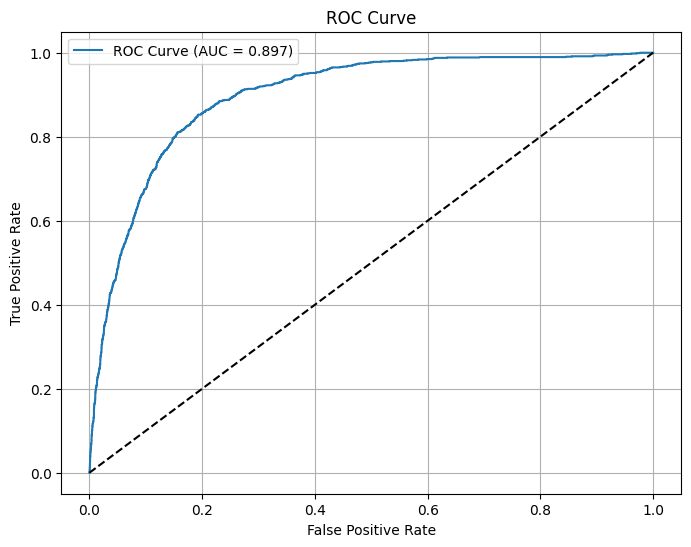

In [19]:
# What : I plot the ROC curve and compute AUC
# Why  : Because ROC shows the model’s ability to distinguish classes
# How  : I use roc_curve and roc_auc_score from sklearn

# 1. I get predicted probabilities
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# 2. I compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

# 3. I plot the ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
